In [1]:

 
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# -*- coding: utf-8 -*-


import pandas as pd, numpy as np


# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import statsmodels

import statsmodels.api as sm

import statsmodels.formula.api as smf

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import os

import sys

from scipy import stats

import matplotlib.pyplot as plt

import seaborn as sns

# %matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression  # Add this import

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

from datetime import date

import holidays

from workalendar.europe import France

import datetime



In [2]:
data = pd.read_csv(r"C:\Users\utilisateur\Downloads\wetransfer_histo_gazpar_merged-3-csv-gz_2026-01-30_1023\histo_gazpar_merged(1).csv.gz")



In [3]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data.shape


(2797952, 35)

In [4]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Adjust pce to 13 numbers

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data['pce']=data['pce'].astype(str)



In [6]:
# data['pce'].apply(len).unique()

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Define a function to add leading zeros if length is less than or equal to 13

def add_leading_zeros(pce_value):

    if len(pce_value) <= 13:

        # Pad the string with leading zeros to make it 14 characters long

        return pce_value.zfill(14)

    else:

        return pce_value

# Apply the function to the 'pce' column

data['pce'] = data['pce'].apply(add_leading_zeros)



In [7]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# data.head()

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# ### !!! DROP¨!!!###

# unique_values = data['pce'].unique()

# # Ensure there are at least 100 unique values to sample

# if len(unique_values) < 100:

#     raise ValueError("The column does not contain at least 100 unique values.")

# # Randomly select 100 unique values from the column

# selected_values = np.random.choice(unique_values, size=100, replace=False)

# # Subset the DataFrame to include only rows with the selected values

# subset_df = data[data['pce'].isin(selected_values)]

# data = subset_df

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Trend per pce

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data = data.sort_values(by=['pce', 'gasday'])

data['trend'] = data.groupby('pce').cumcount() + 1



In [8]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Add workday & week-end

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data['gasday'] = pd.to_datetime(data['gasday']).dt.date

# Function to determine if a day is a workday (Mon-Fri) or weekend (Sat-Sun)

def is_workday(date):

   return 1 if date.weekday() < 5 else 0

# Apply the function to create the Workday column

data['workday'] = data['gasday'].apply(is_workday)

data['weekend'] = 1-data['workday']



In [9]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Add Holidays

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Assuming col 'year'

unique_years = data['year'].unique()

# Convert unique_years to integers and create a list

unique_years_list = unique_years.astype(int).tolist()

# Create an empty dictionary to store the holidays for each year

fr_holidays = {}

# Iterate through unique years and get the public holidays for each year

for year in unique_years_list:

    fr_holidays[year] = holidays.France(years=[year])

# Flatten the holiday dictionary for easier lookup

all_holidays = {date: name for year in fr_holidays for date, name in fr_holidays[year].items()}

all_holidays


# Create a new column indicating whether each date is a public holiday (1 or 0)

data['Is_Public_Holiday'] = data['gasday'].apply(lambda x: 1 if x in all_holidays else 0)

# Create a column with the holiday name or an empty string if it is not a holiday

data['Holiday_Name'] = data['gasday'].apply(lambda x: all_holidays.get(x, ''))



In [10]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Determine if it's a non-working day

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data['non_working_day'] = data['weekend'] | data['Is_Public_Holiday']



In [12]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Count observations per category

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

data['count'] = data.groupby('pce')['pce'].transform('count')



In [13]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Check for missing values and drop rows with missing values

data_nona = data.dropna(subset=['valeur_energie_conso', 'hdd', 'trend', 'pce'])



In [14]:

# Subset the dataset where column 'is_outlier' is not equal to -1

# data_nona = data_nona[data_nona['is_outlier'] != -1]

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# data_nona.shape

data_nona = data_nona[(data_nona['hdd'] != 0) & (data['valeur_energie_conso'] != 0)]



In [16]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# FE weights are related to overall residual variance (Captures "leftover" variability within groups after accounting for both fixed and random effects), RE varince (Captures how much group-specific deviations (random effects) vary around the population average (fixed effects).the RE variance-covariance matrix is used to weight the FE estimates and their uncertainty. The FE estimates are derived by "pooling" group-specific effects, with pooling weights determined by:

# The relative magnitude of within-group vs. between-group variance,

# Correlations between random effects (e.g., intercept-slope covariance).

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Models

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# #%%time

# lmm = smf.mixedlm(

#     formula='valeur_energie_conso ~ hdd * workday + hdd*non_working_day - workday - non_working_day - hdd + trend + 1',

#     data=data_nona,

#     groups="pce",

#     re_formula="~hdd*workday+hdd*non_working_day - workday - non_working_day - hdd + 1"

# ).fit()

# lmm.summary()

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

#%%time

lmm_default = smf.mixedlm(

    formula='valeur_energie_conso ~ hdd + trend + Is_Public_Holiday',

    data=data_nona,

    groups="pce",

    re_formula="~hdd + 1"

).fit()

lmm_default.summary(method=["lbfgs"])



c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 1481335 Method:             REML                
No. Groups:       7957    Scale:              1622429.3752        
Min. group size:  1       Log-Likelihood:     -12694363.1637      
Max. group size:  429     Converged:          No                  
Mean group size:  186.2                                           
------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------
Intercept               8.565    2.770  3.093 0.002   3.137 13.994
hdd                     5.823    0.249 23.412 0.000   5.336  6.311
trend                   0.006    0.008  0.705 0.481  -0.010  0.021
Is_Public_Holiday      -3.646    6.033 -0.604 0.546 -15.470  8.178
pce Var              8552.859                                     
pce x hdd Cov        -556.955                                     
hdd Var                37.010                                     
==================================================================

"""

In [17]:
df_random_effects_default = pd.DataFrame.from_dict(lmm_default.random_effects, orient='index')

In [18]:

df_random_effects_default['Fixed intercept'] = lmm_default.fe_params.loc['Intercept']

df_random_effects_default['Fixed slope trend'] = lmm_default.fe_params.loc['trend']

df_random_effects_default['Fixed slope Is_Public_Holiday'] = lmm_default.fe_params.loc['Is_Public_Holiday']

df_random_effects_default['Fixed slope hdd'] = lmm_default.fe_params.loc['hdd']


In [19]:

df_random_effects_default = df_random_effects_default.rename({

    'pce': 'Random intercept',

    'hdd': 'Random slope hdd'

}, axis=1)



In [20]:

df_random_effects_default['INTERCEPT LMM'] = df_random_effects_default['Random intercept'] + df_random_effects_default['Fixed intercept']

df_random_effects_default['SLOPE LMM hdd'] = df_random_effects_default['Random slope hdd'] + df_random_effects_default['Fixed slope hdd']



In [21]:
df_random_effects = df_random_effects_default



In [22]:

df_random_effects = df_random_effects.reset_index().rename(columns={'index': 'pce'})



In [23]:
df_random_effects


,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd
0,22114761187602,7.051824,-0.434997,8.565324,0.005579,-3.646053,5.823298,15.617148,5.388301
1,22114761188829,27.092570,-1.717639,8.565324,0.005579,-3.646053,5.823298,35.657895,4.105659
2,22114761191548,-9.709267,0.617184,8.565324,0.005579,-3.646053,5.823298,-1.143943,6.440481
3,22114761192886,-1.161910,0.075395,8.565324,0.005579,-3.646053,5.823298,7.403415,5.898692
4,22114761202808,4.526642,-0.287282,8.565324,0.005579,-3.646053,5.823298,13.091966,5.536016
...,...,...,...,...,...,...,...,...,...
7952,22157452873546,-3.840480,0.247940,8.565324,0.005579,-3.646053,5.823298,4.724845,6.071238
7953,22157452876350,-7.247012,0.458581,8.565324,0.005579,-3.646053,5.823298,1.318313,6.281878
7954,22157452887265,9.284888,-0.562030,8.565324,0.005579,-3.646053,5.823298,17.850213,5.261267
7955,22157452890759,-3.651189,0.237431,8.565324,0.005579,-3.646053,5.823298,4.914136,6.060729


In [24]:


df_random_effects_default.columns = [col + '_default' if col in df_random_effects.columns else col for col in df_random_effects_default.columns]


In [25]:

df_random_effects


,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd
0,22114761187602,7.051824,-0.434997,8.565324,0.005579,-3.646053,5.823298,15.617148,5.388301
1,22114761188829,27.092570,-1.717639,8.565324,0.005579,-3.646053,5.823298,35.657895,4.105659
2,22114761191548,-9.709267,0.617184,8.565324,0.005579,-3.646053,5.823298,-1.143943,6.440481
3,22114761192886,-1.161910,0.075395,8.565324,0.005579,-3.646053,5.823298,7.403415,5.898692
4,22114761202808,4.526642,-0.287282,8.565324,0.005579,-3.646053,5.823298,13.091966,5.536016
...,...,...,...,...,...,...,...,...,...
7952,22157452873546,-3.840480,0.247940,8.565324,0.005579,-3.646053,5.823298,4.724845,6.071238
7953,22157452876350,-7.247012,0.458581,8.565324,0.005579,-3.646053,5.823298,1.318313,6.281878
7954,22157452887265,9.284888,-0.562030,8.565324,0.005579,-3.646053,5.823298,17.850213,5.261267
7955,22157452890759,-3.651189,0.237431,8.565324,0.005579,-3.646053,5.823298,4.914136,6.060729


In [26]:

merged_df = df_random_effects


In [27]:

data_nona_unique = data_nona[['pce', 'count']].drop_duplicates(subset='pce')


In [54]:

merged_df['pce'] = merged_df['pce'].astype(str)

data_nona_unique['pce'] = data_nona_unique['pce'].astype(str)

merged_df=pd.merge(merged_df, data_nona_unique[['pce', 'count']], on='pce', how='left')


In [55]:

merged_df


,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd,count_x,count_y
0,22114761187602,7.051824,-0.434997,8.565324,0.005579,-3.646053,5.823298,15.617148,5.388301,466,466
1,22114761188829,27.092570,-1.717639,8.565324,0.005579,-3.646053,5.823298,35.657895,4.105659,290,290
2,22114761191548,-9.709267,0.617184,8.565324,0.005579,-3.646053,5.823298,-1.143943,6.440481,445,445
3,22114761192886,-1.161910,0.075395,8.565324,0.005579,-3.646053,5.823298,7.403415,5.898692,358,358
4,22114761202808,4.526642,-0.287282,8.565324,0.005579,-3.646053,5.823298,13.091966,5.536016,470,470
...,...,...,...,...,...,...,...,...,...,...,...
7952,22157452873546,-3.840480,0.247940,8.565324,0.005579,-3.646053,5.823298,4.724845,6.071238,266,266
7953,22157452876350,-7.247012,0.458581,8.565324,0.005579,-3.646053,5.823298,1.318313,6.281878,470,470
7954,22157452887265,9.284888,-0.562030,8.565324,0.005579,-3.646053,5.823298,17.850213,5.261267,451,451
7955,22157452890759,-3.651189,0.237431,8.565324,0.005579,-3.646053,5.823298,4.914136,6.060729,225,225


In [62]:
import numpy as np
import pandas as pd

# =========================
# A) Base complète + coeffs LMM
# =========================
data_out = data.copy()

data_out['pce'] = data_out['pce'].astype(str)
merged_df['pce'] = merged_df['pce'].astype(str)

cols_needed = [
    'pce',
    'INTERCEPT LMM',
    'SLOPE LMM hdd',
    'Fixed slope trend',
    'Fixed slope Is_Public_Holiday'
]

data_out = pd.merge(
    data_out,
    merged_df[cols_needed].drop_duplicates(subset='pce'),
    on='pce',
    how='inner'
).copy()

# On garde seulement les lignes nécessaires au calcul des résidus
data_out = data_out.dropna(subset=[
    'valeur_energie_conso',
    'hdd',
    'trend',
    'Is_Public_Holiday',
    'INTERCEPT LMM',
    'SLOPE LMM hdd',
    'Fixed slope trend',
    'Fixed slope Is_Public_Holiday'
]).copy()

# =========================
# B) Valeur prédite et résidu
# =========================
data_out['pred_lmm'] = (
    data_out['INTERCEPT LMM']
    + data_out['SLOPE LMM hdd'] * data_out['hdd']
    + data_out['Fixed slope trend'] * data_out['trend']
    + data_out['Fixed slope Is_Public_Holiday'] * data_out['Is_Public_Holiday']
)

data_out['resid_lmm'] = data_out['valeur_energie_conso'] - data_out['pred_lmm']

# =========================
# C) Détection robuste des outliers pce par pce
# =========================
def mad_based_outlier_flag(x, threshold=3.5):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    
    if mad == 0 or pd.isna(mad):
        return pd.Series(False, index=x.index)
    
    robust_z = 0.6745 * (x - med) / mad
    return np.abs(robust_z) > threshold

data_out['is_outlier_resid'] = (
    data_out.groupby('pce', group_keys=False)['resid_lmm']
    .apply(mad_based_outlier_flag)
)

# =========================
# D) Data nettoyée pour les graphes
# =========================
data_clean = data_out.loc[~data_out['is_outlier_resid']].copy()

print(f"Nb lignes data initial : {len(data)}")
print(f"Nb lignes après jointure coeffs : {len(data_out)}")
print(f"Nb outliers retirés : {data_out['is_outlier_resid'].sum()}")
print(f"Nb lignes data_clean : {len(data_clean)}")

Nb lignes data initial : 2797952
Nb lignes après jointure coeffs : 2793859
Nb outliers retirés : 257820
Nb lignes data_clean : 2536039


Base utilisée : data_clean
Première année de référence : 2024
Dernière année observée dans le graphe : 2025
Nb lignes après préparation : 2536039
Nb lignes après filtre présence année 1 : 1381294
Nb jours tracés : 312
Nombre moyen de PCE retenues par jour : 4427
Nombre min de PCE retenues sur un jour : 1683
Nombre max de PCE retenues sur un jour : 5187


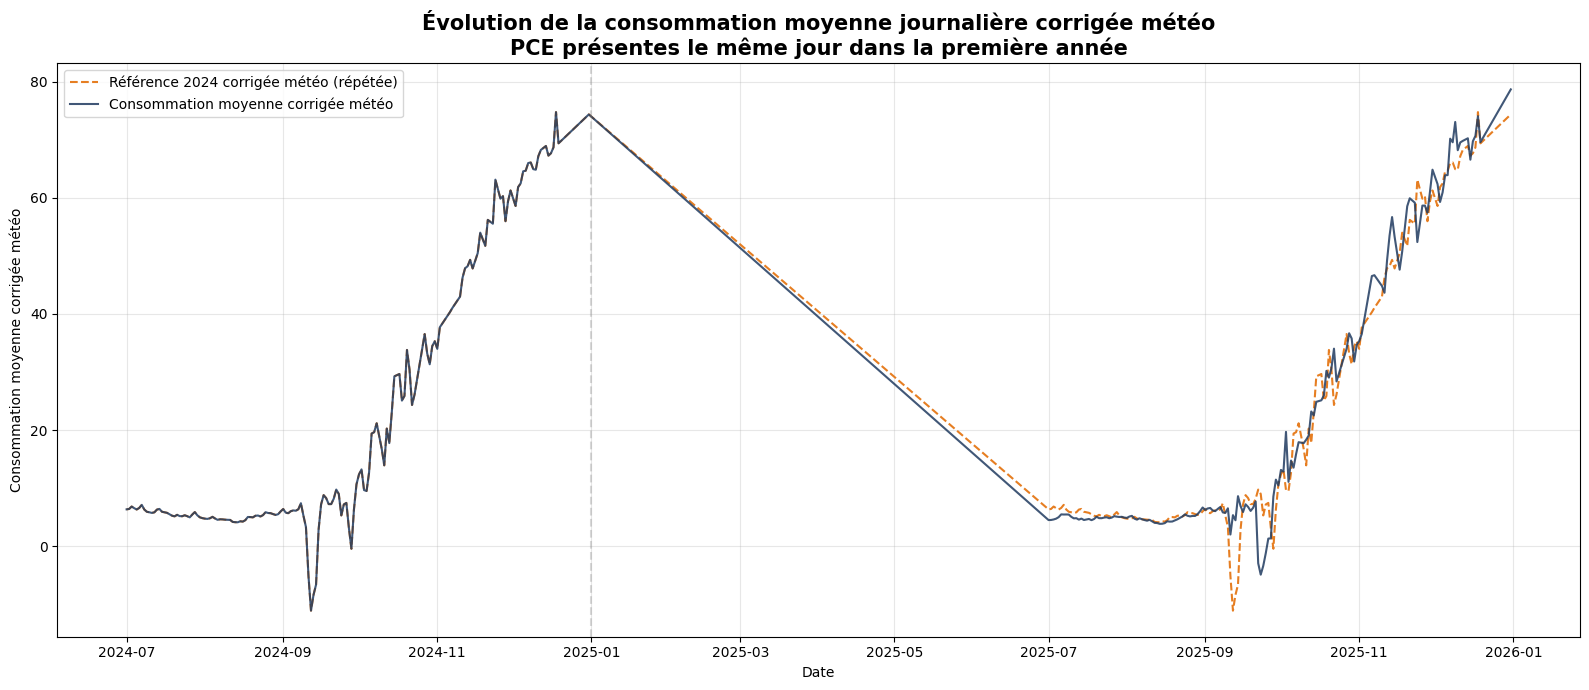

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Base de travail
# =========================
df_plot = data_clean.copy() if 'data_clean' in globals() else data.copy()

df_plot['dateparsed'] = pd.to_datetime(df_plot['gasday'])
df_plot['year'] = df_plot['dateparsed'].dt.year
df_plot['month'] = df_plot['dateparsed'].dt.month
df_plot['day'] = df_plot['dateparsed'].dt.day

# On retire le 29 février pour aligner les années
df_plot = df_plot[~((df_plot['month'] == 2) & (df_plot['day'] == 29))].copy()

# Harmonisation du type de pce
df_plot['pce'] = df_plot['pce'].astype(str)
merged_df['pce'] = merged_df['pce'].astype(str)

# Colonnes minimales requises
required_cols = ['pce', 'gasday', 'valeur_energie_conso', 'hdd', 'hdd_ref']
missing_cols = [c for c in required_cols if c not in df_plot.columns]
if missing_cols:
    raise KeyError(f"Colonnes manquantes dans df_plot : {missing_cols}")

# On garde seulement les lignes nécessaires
df_plot = df_plot.dropna(
    subset=['pce', 'gasday', 'valeur_energie_conso', 'hdd', 'hdd_ref']
).copy()

# Sécurisation des types numériques
df_plot['hdd'] = pd.to_numeric(df_plot['hdd'], errors='coerce')
df_plot['hdd_ref'] = pd.to_numeric(df_plot['hdd_ref'], errors='coerce')
df_plot['valeur_energie_conso'] = pd.to_numeric(df_plot['valeur_energie_conso'], errors='coerce')

df_plot = df_plot.dropna(subset=['hdd', 'hdd_ref', 'valeur_energie_conso']).copy()

# =========================
# 1) SLOPE LMM hdd : éviter la double jointure
# =========================
if 'SLOPE LMM hdd' not in df_plot.columns:
    df_plot = pd.merge(
        df_plot,
        merged_df[['pce', 'SLOPE LMM hdd']].drop_duplicates(subset='pce'),
        on='pce',
        how='inner'
    )

if 'SLOPE LMM hdd' not in df_plot.columns:
    slope_candidates = [c for c in df_plot.columns if 'SLOPE LMM hdd' in c]
    if len(slope_candidates) == 0:
        raise KeyError("Impossible de trouver la colonne 'SLOPE LMM hdd' dans df_plot.")
    df_plot['SLOPE LMM hdd'] = df_plot[slope_candidates[0]]

# =========================
# 2) Correction météo avec la vraie hdd_ref
# =========================
df_plot['delta_hdd'] = df_plot['hdd'] - df_plot['hdd_ref']
df_plot['conso_corr'] = (
    df_plot['valeur_energie_conso']
    - df_plot['SLOPE LMM hdd'] * df_plot['delta_hdd']
)

# =========================
# 3) Première année de référence
# =========================
first_year = int(df_plot['year'].min())

# Univers de référence : PCE présentes par (month, day) en première année
ref_presence = (
    df_plot.loc[df_plot['year'] == first_year, ['month', 'day', 'pce']]
    .drop_duplicates()
)

# =========================
# 4) Garder, pour chaque date observée,
# seulement les PCE présentes aussi ce même jour en première année
# =========================
df_matched = pd.merge(
    df_plot,
    ref_presence,
    on=['month', 'day', 'pce'],
    how='inner'
).copy()

# Si plusieurs lignes par pce/jour, on moyenne avant agrégation finale
df_matched = (
    df_matched
    .groupby(['dateparsed', 'year', 'month', 'day', 'pce'], as_index=False)
    .agg(conso_corr=('conso_corr', 'mean'))
)

# =========================
# 5) Moyenne journalière
# =========================
daily_mean = (
    df_matched
    .groupby('dateparsed', as_index=False)
    .agg(
        mean_conso_corr=('conso_corr', 'mean'),
        nb_pce=('pce', 'nunique')
    )
    .sort_values('dateparsed')
)

daily_mean['year'] = daily_mean['dateparsed'].dt.year
daily_mean['month'] = daily_mean['dateparsed'].dt.month
daily_mean['day'] = daily_mean['dateparsed'].dt.day

# =========================
# 6) Profil de référence = première année répétée
# =========================
ref_profile = (
    daily_mean.loc[daily_mean['year'] == first_year, ['month', 'day', 'mean_conso_corr']]
    .rename(columns={'mean_conso_corr': 'ref_conso_repeated'})
)

plot_df = (
    pd.merge(daily_mean, ref_profile, on=['month', 'day'], how='left')
    .set_index('dateparsed')
    .sort_index()
)

# =========================
# 7) Diagnostics
# =========================
base_name = 'data_clean' if 'data_clean' in globals() else 'data'
last_year = int(plot_df.index.max().year)

print(f"Base utilisée : {base_name}")
print(f"Première année de référence : {first_year}")
print(f"Dernière année observée dans le graphe : {last_year}")
print(f"Nb lignes après préparation : {len(df_plot)}")
print(f"Nb lignes après filtre présence année 1 : {len(df_matched)}")
print(f"Nb jours tracés : {len(plot_df)}")
print(f"Nombre moyen de PCE retenues par jour : {plot_df['nb_pce'].mean():.0f}")
print(f"Nombre min de PCE retenues sur un jour : {plot_df['nb_pce'].min():.0f}")
print(f"Nombre max de PCE retenues sur un jour : {plot_df['nb_pce'].max():.0f}")

# =========================
# 8) Graphique
# =========================
plt.figure(figsize=(16, 7))

plt.plot(
    plot_df.index,
    plot_df['ref_conso_repeated'],
    label=f"Référence {first_year} corrigée météo (répétée)",
    color="#E67E22",
    linewidth=1.5,
    linestyle="--"
)

plt.plot(
    plot_df.index,
    plot_df['mean_conso_corr'],
    label="Consommation moyenne corrigée météo",
    color="#1F3A5F",
    linewidth=1.5,
    alpha=0.85
)

min_year = plot_df.index.min().year
max_year = plot_df.index.max().year

for y in range(min_year + 1, max_year + 1):
    plt.axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linestyle="--", alpha=0.3)

plt.title(
    "Évolution de la consommation moyenne journalière corrigée météo\n"
    "PCE présentes le même jour dans la première année",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Consommation moyenne corrigée météo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Base utilisée : data_clean
Première année de référence : 2024
Dernière année observée dans le graphe : 2025
Nb lignes après préparation : 2536039
Nb lignes après filtre panel de référence : 1381294
Nb jours tracés : 312
Nombre moyen de PCE observées par jour : 4427
Nombre min de PCE observées sur un jour : 1683
Nombre max de PCE observées sur un jour : 5187
Taille moyenne du panel de référence : 4804
Taux de couverture moyen : 91.97%


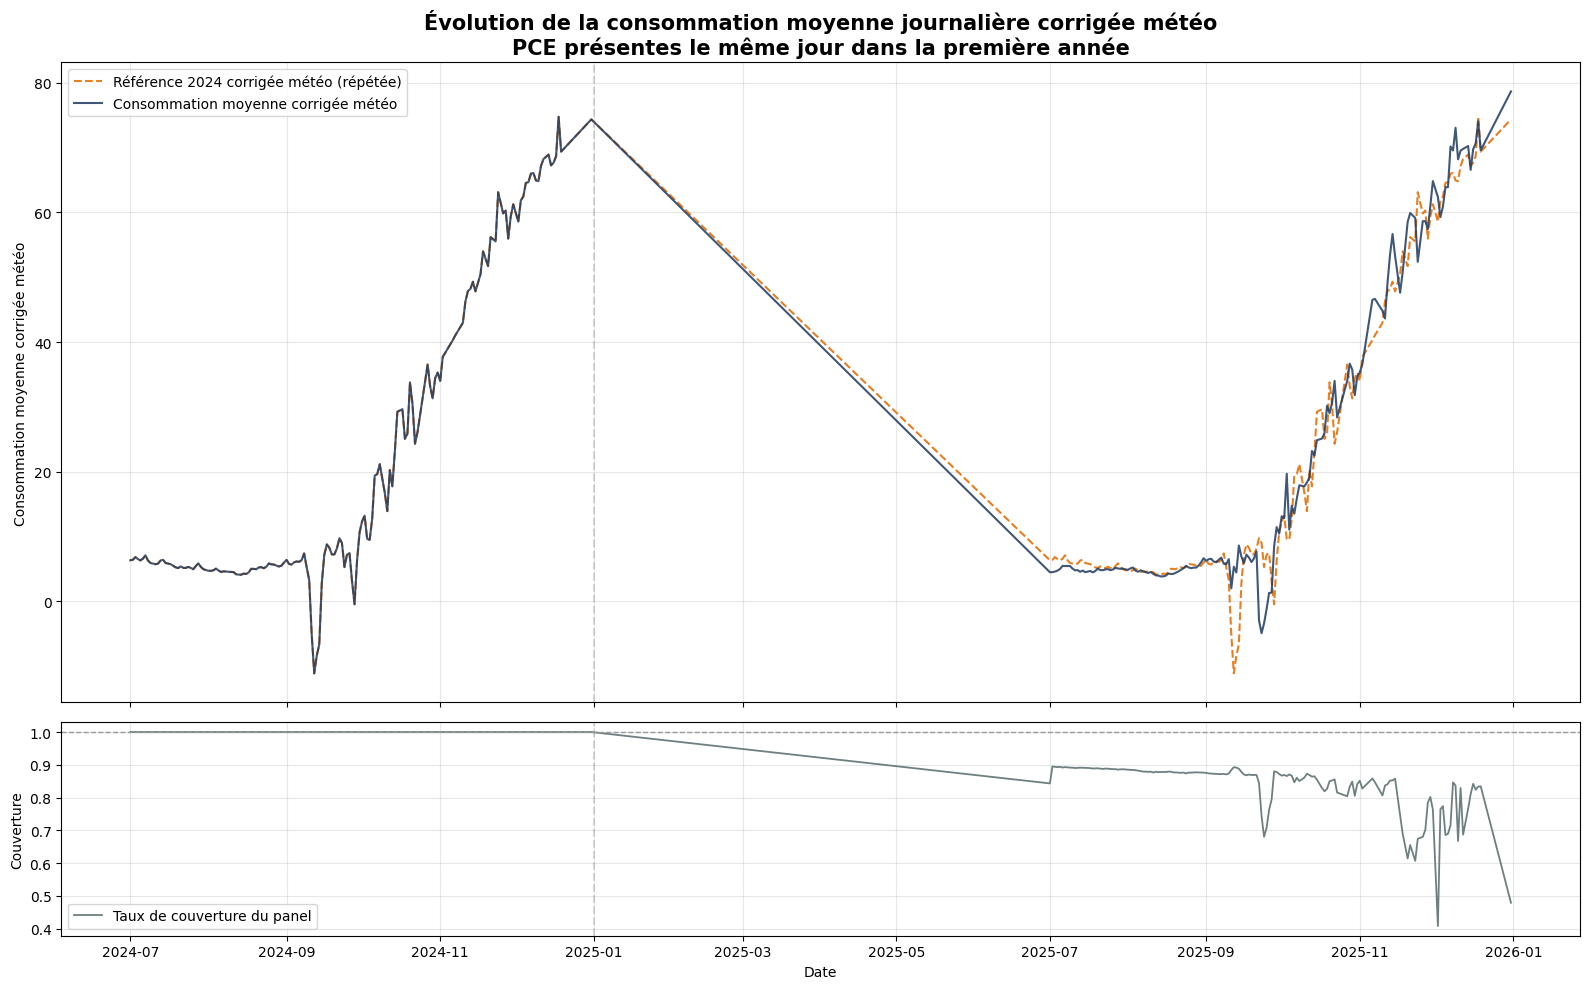

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Base de travail
# =========================
df_plot = data_clean.copy() if 'data_clean' in globals() else data.copy()

df_plot['dateparsed'] = pd.to_datetime(df_plot['gasday'])
df_plot['year'] = df_plot['dateparsed'].dt.year
df_plot['month'] = df_plot['dateparsed'].dt.month
df_plot['day'] = df_plot['dateparsed'].dt.day

# On retire le 29 février pour aligner les années
df_plot = df_plot[~((df_plot['month'] == 2) & (df_plot['day'] == 29))].copy()

# Harmonisation du type de pce
df_plot['pce'] = df_plot['pce'].astype(str)
merged_df['pce'] = merged_df['pce'].astype(str)

# Colonnes minimales requises
required_cols = ['pce', 'gasday', 'valeur_energie_conso', 'hdd', 'hdd_ref']
missing_cols = [c for c in required_cols if c not in df_plot.columns]
if missing_cols:
    raise KeyError(f"Colonnes manquantes dans df_plot : {missing_cols}")

# On garde seulement les lignes utiles
df_plot = df_plot.dropna(
    subset=['pce', 'gasday', 'valeur_energie_conso', 'hdd', 'hdd_ref']
).copy()

# Types numériques
df_plot['hdd'] = pd.to_numeric(df_plot['hdd'], errors='coerce')
df_plot['hdd_ref'] = pd.to_numeric(df_plot['hdd_ref'], errors='coerce')
df_plot['valeur_energie_conso'] = pd.to_numeric(df_plot['valeur_energie_conso'], errors='coerce')

df_plot = df_plot.dropna(subset=['hdd', 'hdd_ref', 'valeur_energie_conso']).copy()

# =========================
# 1) Récupération de la pente LMM sans double jointure
# =========================
if 'SLOPE LMM hdd' not in df_plot.columns:
    df_plot = pd.merge(
        df_plot,
        merged_df[['pce', 'SLOPE LMM hdd']].drop_duplicates(subset='pce'),
        on='pce',
        how='inner'
    )

if 'SLOPE LMM hdd' not in df_plot.columns:
    slope_candidates = [c for c in df_plot.columns if 'SLOPE LMM hdd' in c]
    if len(slope_candidates) == 0:
        raise KeyError("Impossible de trouver la colonne 'SLOPE LMM hdd' dans df_plot.")
    df_plot['SLOPE LMM hdd'] = df_plot[slope_candidates[0]]

# =========================
# 2) Correction météo avec la vraie hdd_ref
# =========================
df_plot['delta_hdd'] = df_plot['hdd'] - df_plot['hdd_ref']
df_plot['conso_corr'] = (
    df_plot['valeur_energie_conso']
    - df_plot['SLOPE LMM hdd'] * df_plot['delta_hdd']
)

# =========================
# 3) Année de référence
# =========================
first_year = int(df_plot['year'].min())

# PCE de référence par jour de l'année (mois, jour) en année 1
ref_presence = (
    df_plot.loc[df_plot['year'] == first_year, ['month', 'day', 'pce']]
    .drop_duplicates()
)

# Taille théorique du panel de référence par jour de l'année
ref_panel_size = (
    ref_presence
    .groupby(['month', 'day'], as_index=False)
    .agg(nb_pce_ref=('pce', 'nunique'))
)

# =========================
# 4) Pour chaque date observée,
# garder seulement les PCE présentes aussi ce même jour en année 1
# =========================
df_matched = pd.merge(
    df_plot,
    ref_presence,
    on=['month', 'day', 'pce'],
    how='inner'
).copy()

# Si plusieurs lignes par pce/jour, on moyenne d'abord au niveau pce-jour
df_matched = (
    df_matched
    .groupby(['dateparsed', 'year', 'month', 'day', 'pce'], as_index=False)
    .agg(conso_corr=('conso_corr', 'mean'))
)

# =========================
# 5) Agrégation journalière
# =========================
daily_mean = (
    df_matched
    .groupby('dateparsed', as_index=False)
    .agg(
        mean_conso_corr=('conso_corr', 'mean'),
        nb_pce_obs=('pce', 'nunique')
    )
    .sort_values('dateparsed')
)

daily_mean['year'] = daily_mean['dateparsed'].dt.year
daily_mean['month'] = daily_mean['dateparsed'].dt.month
daily_mean['day'] = daily_mean['dateparsed'].dt.day

# Ajout de la taille théorique du panel de référence
daily_mean = pd.merge(
    daily_mean,
    ref_panel_size,
    on=['month', 'day'],
    how='left'
)

daily_mean['coverage_rate'] = daily_mean['nb_pce_obs'] / daily_mean['nb_pce_ref']

# =========================
# 6) Profil de référence répété
# =========================
ref_profile = (
    daily_mean.loc[daily_mean['year'] == first_year, ['month', 'day', 'mean_conso_corr']]
    .drop_duplicates(subset=['month', 'day'])
    .rename(columns={'mean_conso_corr': 'ref_conso_repeated'})
)

plot_df = (
    pd.merge(daily_mean, ref_profile, on=['month', 'day'], how='left')
    .set_index('dateparsed')
    .sort_index()
)

# =========================
# 7) Diagnostics
# =========================
base_name = 'data_clean' if 'data_clean' in globals() else 'data'
last_year = int(plot_df.index.max().year)

print(f"Base utilisée : {base_name}")
print(f"Première année de référence : {first_year}")
print(f"Dernière année observée dans le graphe : {last_year}")
print(f"Nb lignes après préparation : {len(df_plot)}")
print(f"Nb lignes après filtre panel de référence : {len(df_matched)}")
print(f"Nb jours tracés : {len(plot_df)}")
print(f"Nombre moyen de PCE observées par jour : {plot_df['nb_pce_obs'].mean():.0f}")
print(f"Nombre min de PCE observées sur un jour : {plot_df['nb_pce_obs'].min():.0f}")
print(f"Nombre max de PCE observées sur un jour : {plot_df['nb_pce_obs'].max():.0f}")
print(f"Taille moyenne du panel de référence : {plot_df['nb_pce_ref'].mean():.0f}")
print(f"Taux de couverture moyen : {plot_df['coverage_rate'].mean():.2%}")

# =========================
# 8) Graphiques
# =========================
fig, axes = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Graphique principal
axes[0].plot(
    plot_df.index,
    plot_df['ref_conso_repeated'],
    label=f"Référence {first_year} corrigée météo (répétée)",
    color="#E67E22",
    linewidth=1.5,
    linestyle="--"
)

axes[0].plot(
    plot_df.index,
    plot_df['mean_conso_corr'],
    label="Consommation moyenne corrigée météo",
    color="#1F3A5F",
    linewidth=1.5,
    alpha=0.85
)

min_year = plot_df.index.min().year
max_year = plot_df.index.max().year

for y in range(min_year + 1, max_year + 1):
    axes[0].axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linestyle="--", alpha=0.3)
    axes[1].axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linestyle="--", alpha=0.3)

axes[0].set_title(
    "Évolution de la consommation moyenne journalière corrigée météo\n"
    "PCE présentes le même jour dans la première année",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_ylabel("Consommation moyenne corrigée météo")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sous-graphique de couverture du panel
axes[1].plot(
    plot_df.index,
    plot_df['coverage_rate'],
    color="#6E7F80",
    linewidth=1.3,
    label="Taux de couverture du panel"
)
axes[1].axhline(1.0, color="#999999", linestyle="--", linewidth=1)

axes[1].set_ylabel("Couverture")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()